**Nifty 50 Stock Prices Simulation**

In [ ]:
# Objective : Simulate future stock prices (Nifty 50) using NumPy vectorization and geometric brownian motion.
# About the project :
# - uses Nifty 50 historical stock prices data (2000-2025)
# - computes and simulates future stock prices (for the next year) using the concept of geometric brownian motion.
# - visualizes future price paths and finds expected price, worst-case and best-case scenarios over a year along with confidence intervals

# Phased approach:
# Phase 1 — Data Prep
# Load historical prices
# compute daily returns
# compute mean & std

# Phase 2 — Simulation
# Using NumPy:
# simulate 1000 future price paths
# horizon: 252 days
# use geometric Brownian motion

# Phase 3 — Analysis
# Compute:
# expected price
# worst-case scenario
# best-case scenario
# volatility bands

# Phase 4 — Visualization
# Plot:
# sample paths
# distribution histogram
# confidence interval bands

Data Preparation

In [ ]:
# importing libraries
import numpy as np
import pandas as pd

# loading Nifty 50 historical prices dataset
data = pd.read_csv("data.csv")
print(data.head(),"\n",type(data),"\n") # inspecting the data

         Date     Open     High      Low   Close
0  2000-01-03  1482.15  1592.90  1482.15  1592.2
1  2000-01-04  1594.40  1641.95  1594.40  1638.7
2  2000-01-05  1634.55  1635.50  1555.05  1595.8
3  2000-01-06  1595.80  1639.00  1595.80  1617.6
4  2000-01-07  1616.60  1628.25  1597.20  1613.3 
 <class 'pandas.core.frame.DataFrame'> 



In [ ]:
# converting the data (pandas dataframe) to a 2D numpy array
data_array = np.array(data)
print(data_array[:8],"\n") # inspecting few top rows of the array

[['2000-01-03' 1482.15 1592.9 1482.15 1592.2]
 ['2000-01-04' 1594.4 1641.95 1594.4 1638.7]
 ['2000-01-05' 1634.55 1635.5 1555.05 1595.8]
 ['2000-01-06' 1595.8 1639.0 1595.8 1617.6]
 ['2000-01-07' 1616.6 1628.25 1597.2 1613.3]
 ['2000-01-10' 1615.65 1662.1 1614.95 1632.9]
 ['2000-01-11' 1633.25 1639.9 1548.25 1572.5]
 ['2000-01-12' 1572.3 1631.55 1571.7 1624.8]] 



In [ ]:
# calculating daily differences between stock's daily consecutive close values
# (daily_diff = today's closing price - yesterday's closing price)
print("daily differences:")
daily_diff = np.round(np.diff(data_array[:,-1].astype(float),axis=0),3)
print(daily_diff[:5],"\n")

daily differences:
[ 46.5 -42.9  21.8  -4.3  19.6] 



In [ ]:
# calculating daily returns as : daily_difference / yesterday's closing price
print("daily returns:")
daily_returns = np.round(daily_diff/(data_array[:data_array.shape[0]-1,-1].astype(float)),3)
print(daily_returns[:5],"\n")
daily_returns = daily_returns.reshape(-1,1)

# adding dates alongside to get date-wise daily returns
print("date-wise daily returns:")
date_wise_daily_returns = np.concatenate((data_array[1:,0].reshape(-1,1),daily_returns),axis=1)
print(date_wise_daily_returns[:5],"\n")

# date-wise daily returns in %
print("date-wise daily returns (in %):")
date_wise_daily_returns_pct = date_wise_daily_returns.copy()
date_wise_daily_returns_pct[:,-1] = np.round((date_wise_daily_returns_pct[:,-1]*100).astype(float),3)
print(date_wise_daily_returns_pct[:5],"\n")

daily returns:
[ 0.029 -0.026  0.014 -0.003  0.012] 

date-wise daily returns:
[['2000-01-04' 0.029]
 ['2000-01-05' -0.026]
 ['2000-01-06' 0.014]
 ['2000-01-07' -0.003]
 ['2000-01-10' 0.012]] 

date-wise daily returns (in %):
[['2000-01-04' 2.9]
 ['2000-01-05' -2.6]
 ['2000-01-06' 1.4]
 ['2000-01-07' -0.3]
 ['2000-01-10' 1.2]] 



In [ ]:
# calculating mean and standard deviation of date-wise daily returns
print("mean of daily returns:",np.round(np.mean(date_wise_daily_returns_pct[:,-1],axis=0),3))
print("standard deviation of daily returns:",np.round(np.std(date_wise_daily_returns_pct[:,-1],axis=0),3))

mean of daily returns: 0.053
standard deviation of daily returns: 1.377


Simulation using Geometric Brownian Motion

In [ ]:
# About geometric brownian motion:
# It is a continuous-time stochastic process where the logarithm of a randomly varying quantity follows a Brownian motion with drift.
# It is widely used to model stock prices and ensures positive values, with the price following a log-normal distribution, representing proportional returns

# Data Preparation and Parameter Estimation for Geometric Brownian Motion
# Starting Price (S0)
# Annual drift (u) = average log - daily return
# Annual volatility (sigma) = std deviation of log - daily returns

print("Simulating 1000 future paths using Geometric Brownian Motion:")

# calculating ratio of daily prices
ratio_daily_prices = data_array[1:,-1]/data_array[:data_array.shape[0]-1,-1]
print("ratio of daily prices:")
print(np.round((ratio_daily_prices[:5].astype(float)),3))

# taking logarithm of ratio of daily prices
log_ratio_daily_prices = np.log(ratio_daily_prices.astype(float))
print("logarithm of ratio of daily prices:")
print(np.round((log_ratio_daily_prices[:5]).astype(float),3),"\n")

# calculating drift, volatility and starting price (So)
drift = np.mean(log_ratio_daily_prices)
volatility = np.std(log_ratio_daily_prices)
So = data_array[-1,-1] # setting starting price as the latest updated stock price in the dataset
print("drift (mean of daily log returns):",np.mean(log_ratio_daily_prices))
print("volatility (std deviation of daily log returns):",np.std(log_ratio_daily_prices))
print("starting price (So, the most recent closing price):",data_array[-1,-1])

Simulating 1000 future paths using Geometric Brownian Motion:
ratio of daily prices:
[1.029 0.974 1.014 0.997 1.012]
logarithm of ratio of daily prices:
[ 0.029 -0.027  0.014 -0.003  0.012] 

drift (mean of daily log returns): 0.0004361427171583623
volatility (std deviation of daily log returns): 0.013795219664058769
starting price (So, the most recent closing price): 25001.15


In [ ]:
# The Simulation Setup for geometric brownian motion
T = 252  # 252 days in a stock market year
t = 1   # daily
paths = 1000  # 1000 different paths to simulate
Z = np.random.standard_normal((252,1000))  # random standard normal distribution to take samples from, 1000 values for 252 days

# GBM discrete formula : S(t+1) = S(t) x exp((drift - volatility**2/2)t + volatility*sqrt(t)Z)

# daily "multiplier" for every single step in every path
daily_growth = np.exp((drift - (volatility**2 / 2)) + volatility * Z)

future_price_paths = np.zeros((T+1,paths),dtype="float")
future_price_paths[0] = So
future_price_paths[1:] = daily_growth
future_price_paths = np.cumprod(future_price_paths,axis=0)
# print(np.round(future_price_paths[:5],3))
print("future price paths:")
print(np.round(future_price_paths[-1:-4:-1],3))

future price paths:
[[32753.161 32532.006 30462.785 ... 21996.478 33561.325 18927.451]
 [32600.146 32536.977 30502.781 ... 22461.358 33586.906 18970.645]
 [32208.257 31747.141 31027.909 ... 22323.615 33496.454 19079.242]]


Analysis and Visualization

In [ ]:
# printing expected price after 1 year, minimum and maximum price expected of Nifty 50
print("expected price after 1 year:",np.mean(future_price_paths[-1:],axis=1))
print("worst-case scenario:",np.min(future_price_paths[-1:],axis=1))
print("best-case scenario:",np.max(future_price_paths[-1:],axis=1))

expected price after 1 year: [27892.72749498]
worst-case scenario: [14829.87021161]
best-case scenario: [52410.61903239]


(array([1.6070e+03, 3.1254e+04, 1.1739e+05, 7.0228e+04, 2.3546e+04,
        6.5260e+03, 1.9350e+03, 3.2000e+02, 1.3000e+02, 6.4000e+01]),
 array([13834.01577174, 18098.75074278, 22363.48571382, 26628.22068487,
        30892.95565591, 35157.69062695, 39422.425598  , 43687.16056904,
        47951.89554008, 52216.63051113, 56481.36548217]),
 <BarContainer object of 10 artists>)

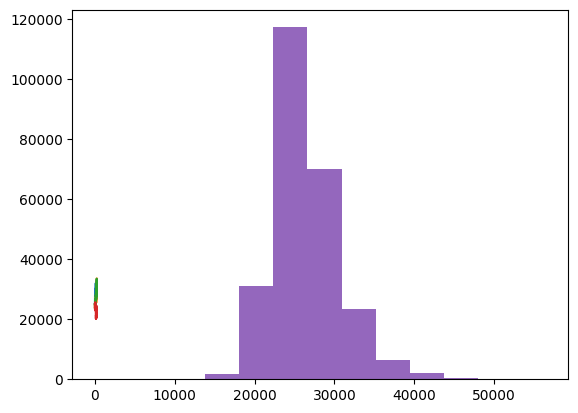

In [ ]:
# plotting graph for simulated future paths visualization
# importing matplotlib for plotting
import matplotlib.pyplot as plt

# plotting a histogram of future price path values
plt.plot(future_price_paths[:, :4])
plt.hist(future_price_paths.flatten())

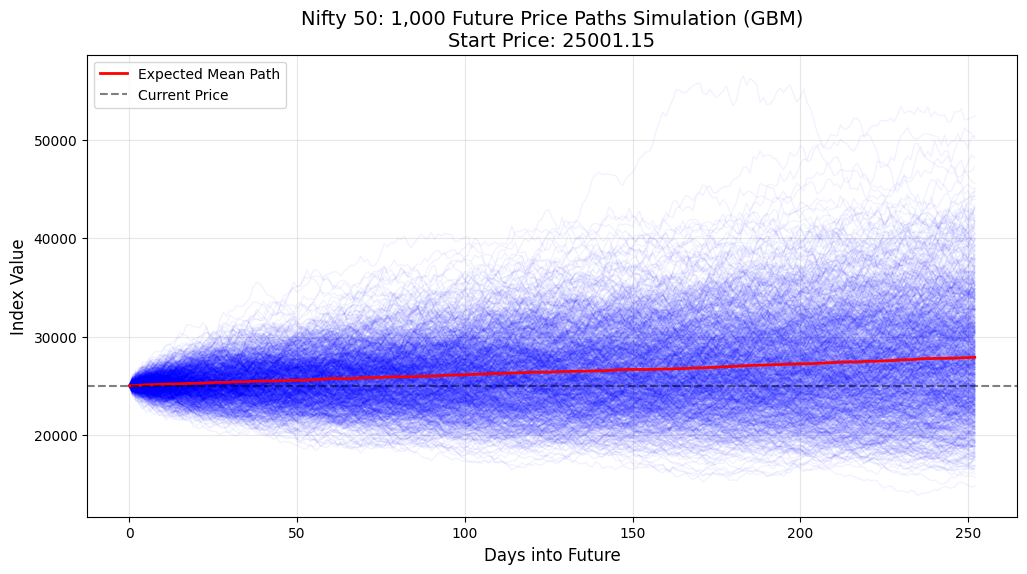

Mean Expected Price after 1 year: 27892.73
95% Confidence Interval: [18225.70, 41504.25]


In [ ]:
# plotting time series plot with future day-wise expected price

plt.figure(figsize=(12, 6))
# Plot all 1000 paths with low transparency (alpha) to see the "density"
plt.plot(future_price_paths, color='blue', alpha=0.05, linewidth=1)

# Plot the Mean Path (the average of all simulations) in Red
mean_path = np.mean(future_price_paths, axis=1)
plt.plot(mean_path, color='red', linewidth=2, label='Expected Mean Path')

# Formatting the Chart
plt.title(f"Nifty 50: 1,000 Future Price Paths Simulation (GBM)\nStart Price: {So:.2f}", fontsize=14)
plt.xlabel("Days into Future", fontsize=12)
plt.ylabel("Index Value", fontsize=12)
plt.axhline(So, color='black', linestyle='--', alpha=0.5, label='Current Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Quick summary statistics
final_prices = future_price_paths[-1]
print(f"Mean Expected Price after 1 year: {np.mean(final_prices):.2f}")
print(f"95% Confidence Interval: [{np.percentile(final_prices, 2.5):.2f}, {np.percentile(final_prices, 97.5):.2f}]")

Key findings:
- Nifty 50 is expected to have a price of around Rs. 27,892.73 in May, 2026.
- It's expected to reach as low as Rs. 18,225.70 and as high as Rs. 41,504.25 in the year.

Note : this is all considering that no discontinuities or sudden price jumps occur, often seen as a limitation of Goemetric brownian motion which assumes constant volatility leading to sometimes non-consideration of realistic events such as times of wars, other geopolitical and economical events and related factors, etc.